# Adversarial attacks for CV models with foolbox

## System preparation

Imports and general configuration.

In [1]:
!pip -q install foolbox

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 31.2 MB/s eta 0:00:00


In [2]:
import os
import math
import copy
import tarfile
import random
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset

from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights

import foolbox as fb
from tqdm.auto import tqdm

plt.rcParams["figure.figsize"] = (10, 5)

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True

## Dataset

`CUB_200_2011` dataset download.

In [3]:
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]
MEAN = torch.tensor(mean, device=device).view(1, 3, 1, 1)
STD = torch.tensor(std, device=device).view(1, 3, 1, 1)

root = Path("/content/cub")
data_url = "https://data.caltech.edu/records/65de6-vp158/files/CUB_200_2011.tgz?download=1"
archive_path = root / "CUB_200_2011.tgz"
extract_path = root / "CUB_200_2011"

root.mkdir(parents=True, exist_ok=True)
if not extract_path.exists():
    if not archive_path.exists():
        urllib.request.urlretrieve(data_url, archive_path)
    with tarfile.open(archive_path) as tar:
        tar.extractall(path=root)

print(device)
print(extract_path)

/tmp/ipykernel_2221/1590052313.py:16: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=root)


cuda
/content/cub/CUB_200_2011


Torch-like dataset class.

In [4]:
class CUB200(Dataset):
    def __init__(self, root, train=True, transform=None):
        self.root = Path(root)
        self.transform = transform

        images = pd.read_csv(self.root / "images.txt", sep=" ", header=None, names=["id", "path"])
        labels = pd.read_csv(self.root / "image_class_labels.txt", sep=" ", header=None, names=["id", "label"])
        split = pd.read_csv(self.root / "train_test_split.txt", sep=" ", header=None, names=["id", "train"])
        classes = pd.read_csv(self.root / "classes.txt", sep=" ", header=None, names=["label", "name"])

        frame = images.merge(labels, on="id").merge(split, on="id")
        frame["label"] = frame["label"] - 1
        classes["label"] = classes["label"] - 1

        frame["name"] = frame["label"].map(classes.set_index("label")["name"])
        frame = frame[frame["train"] == int(train)].reset_index(drop=True)

        self.frame = frame
        self.classes = classes.sort_values("label")["name"].tolist()

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        image = Image.open(self.root / "images" / row.path).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)
        return image, int(row.label)

Hold-out split for unbalanced data.

In [5]:
def stratified_split(labels, val_frac=0.1, seed=42):
    rng = np.random.default_rng(seed)
    labels = np.asarray(labels)
    train_idx = []
    val_idx = []
    for c in np.unique(labels):
        idx = np.where(labels == c)[0]
        rng.shuffle(idx)
        cut = max(1, int(round(len(idx) * val_frac)))
        val_idx.extend(idx[:cut].tolist())
        train_idx.extend(idx[cut:].tolist())
    rng.shuffle(train_idx)
    rng.shuffle(val_idx)
    return train_idx, val_idx

Transformations needed to adapt the data to the ResNet model.

In [16]:
train_tf = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

eval_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

raw_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
])

Transformed datasets.

In [17]:
train_full = CUB200(extract_path, train=True, transform=train_tf)
train_raw_full = CUB200(extract_path, train=True, transform=raw_tf)
test_full = CUB200(extract_path, train=False, transform=eval_tf)
test_raw_full = CUB200(extract_path, train=False, transform=raw_tf)

train_idx, val_idx = stratified_split(train_full.frame["label"].to_numpy(), val_frac=0.1, seed=seed)

train_ds = Subset(train_full, train_idx)
val_ds = Subset(CUB200(extract_path, train=True, transform=eval_tf), val_idx)
train_raw_ds = Subset(train_raw_full, train_idx)
val_raw_ds = Subset(CUB200(extract_path, train=True, transform=raw_tf), val_idx)

Dataloaders.

In [18]:
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=128, shuffle=False, num_workers=0, pin_memory=True)
train_raw_loader = DataLoader(train_raw_ds, batch_size=64, shuffle=True, num_workers=0, pin_memory=True)
val_raw_loader = DataLoader(val_raw_ds, batch_size=128, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_full, batch_size=128, shuffle=False, num_workers=0, pin_memory=True)
test_raw_loader = DataLoader(test_raw_full, batch_size=128, shuffle=False, num_workers=0, pin_memory=True)

Data examples for preview.

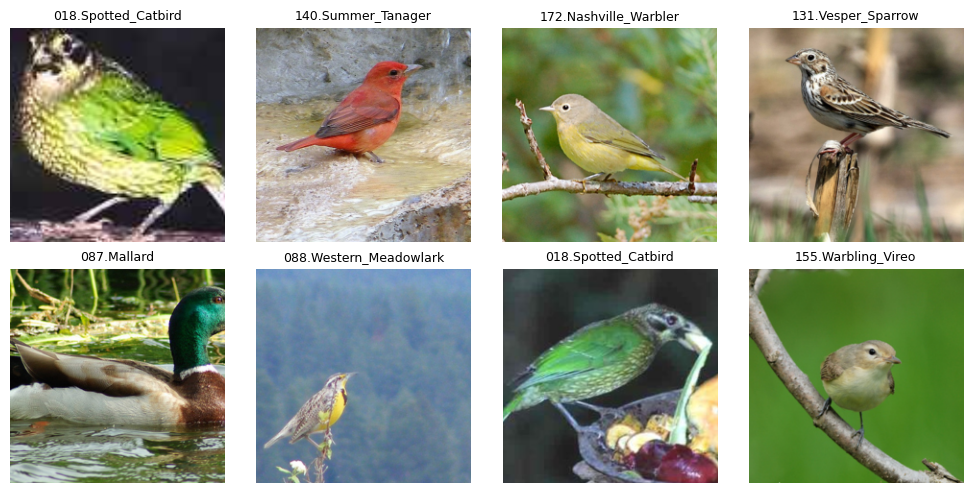

In [19]:
vis_ds = CUB200(extract_path, train=True, transform=raw_tf)

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
idxs = np.random.default_rng(seed).choice(len(vis_ds), size=8, replace=False)

for ax, idx in zip(axes.ravel(), idxs):
    x, y = vis_ds[idx]
    ax.imshow(x.permute(1, 2, 0))
    ax.set_title(vis_ds.classes[y], fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

Boundary attack and randomised smoothing examples.

In [20]:
rng = np.random.default_rng(seed)
all_ids = rng.choice(len(test_raw_full), size=96, replace=False)

boundary_ids = all_ids[:16]
smooth_ids = all_ids[16:80]
attack_ids = all_ids[80:]

attack_loader = DataLoader(Subset(test_raw_full, attack_ids.tolist()), batch_size=16, shuffle=False)
boundary_loader = DataLoader(Subset(test_raw_full, boundary_ids.tolist()), batch_size=4, shuffle=False)

len(train_ds), len(val_ds), len(test_full)

(5394, 600, 5794)

## Modeling

ResNet18 starts from ImageNet weights and gets a new classification head for the 200 bird species. A baseline run.

In [21]:
def make_model():
    model = resnet18(weights=ResNet18_Weights.DEFAULT)
    model.fc = nn.Linear(model.fc.in_features, 200)
    return model.to(device)

def raw_logits(model, x):
    return model((x - MEAN) / STD)

@torch.no_grad()
def accuracy_normalized(model, loader):
    model.eval()
    correct = total = 0
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        pred = model(x).argmax(1)
        correct += (pred == y).sum().item()
        total += y.size(0)
    return correct / total

@torch.no_grad()
def accuracy_raw(model, loader):
    model.eval()
    correct = total = 0
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        pred = raw_logits(model, x).argmax(1)
        correct += (pred == y).sum().item()
        total += y.size(0)
    return correct / total

def train_epochs(model, train_loader, val_loader, epochs=3, lr=3e-4):
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scaler = torch.cuda.amp.GradScaler(enabled=device.type == "cuda")
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0
        total = 0

        for x, y in tqdm(train_loader, desc=f"epoch {epoch}", leave=False):
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            opt.zero_grad(set_to_none=True)
            with torch.autocast("cuda", enabled=device.type == "cuda"):
                loss = F.cross_entropy(model(x), y)
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()

            total_loss += loss.item() * y.size(0)
            total += y.size(0)

        val_acc = accuracy_normalized(model, val_loader)
        history.append({"epoch": epoch, "loss": total_loss / total, "val_acc": val_acc})
        print(f"epoch {epoch}: loss={total_loss / total:.4f}, val_acc={val_acc:.4f}")

    return pd.DataFrame(history)

6 epochs at 3e-4 are enough for convergence to 64%; 2 further epochs at 5e-5 increase the validation accuracy to 70%.

In [ ]:
baseline = make_model()

In [23]:
baseline_hist = train_epochs(baseline, train_loader, val_loader, epochs=2, lr=0.5e-4)

/tmp/ipykernel_2221/948826974.py:35: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=device.type == "cuda")


epoch 1:   0%|          | 0/85 [00:00<?, ?it/s]

epoch 1: loss=0.1297, val_acc=0.6983


epoch 2:   0%|          | 0/85 [00:00<?, ?it/s]

epoch 2: loss=0.0807, val_acc=0.7067


Test evaluation.

In [25]:
baseline_clean_test = accuracy_normalized(baseline, test_loader)
baseline_clean_val = accuracy_normalized(baseline, val_loader)

print(f"baseline val accuracy:  {baseline_clean_val:.4f}")
print(f"baseline test accuracy: {baseline_clean_test:.4f}")

baseline val accuracy:  0.7067
baseline test accuracy: 0.7339


## Foolbox

Foolbox wants inputs in the original image range, so the raw loaders stay in `[0, 1]` and the preprocessing is passed through the wrapper.

In [27]:
def make_fmodel(model):
    return fb.PyTorchModel(
        model,
        bounds=(0, 1),
        preprocessing=dict(mean=mean, std=std, axis=-3),
        device=device,
    )

Benign accuracy is a normal accuracy on natural images from your validation or test set. It shows how well the model performs under normal conditions. Formula:

$$Acc_{benign} = \frac{1}{N} \sum_{i=1}^{N} \mathbb{I}(f(x_i) = y_i)$$

Adversarial accuracy is the accuracy of the model on images that have been specifically modified by an attack. Formula:

$$Acc_{adv} = \frac{1}{N} \sum_{i=1}^{N} \mathbb{I}(f(x_i + \delta) = y_i)$$

If Benign Acc is 70% but the Adv Acc is 5%, the model is very accurate but easy to hack.

In [28]:
def eval_attack_curve(model, attack, loader, epsilons):
    fmodel = make_fmodel(model)
    model.eval()

    clean_correct = 0
    total = 0
    adv_correct = np.zeros(len(epsilons), dtype=np.float64)

    for x, y in tqdm(loader, leave=False):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        clean_correct += (raw_logits(model, x).argmax(1) == y).sum().item()
        total += y.size(0)

        result = attack(fmodel, x, y, epsilons=epsilons)
        if len(result) == 3:
            _, advs, _ = result
        else:
            advs = result[1]

        for i, adv in enumerate(advs):
            adv_correct[i] += (raw_logits(model, adv).argmax(1) == y).sum().item()

    return clean_correct / total, adv_correct / total

### PGD

PGD (Projected Gradient Descent) is a powerful iterative attack that finds the most damaging perturbation within a small neighborhoud of the original image. Formula:

$$x_{t+1} = \Pi_{x+\mathcal{S}} \left( x_t + \alpha \cdot \text{sign}(\nabla_{x_t} L(\theta, x_t, y)) \right)$$

In [48]:
epsilons = [0.0, 1 / 255, 2 / 255, 4 / 255]
pgd_attack = fb.attacks.PGD(steps=10, random_start=True)

baseline_clean_attack, baseline_pgd_acc = eval_attack_curve(baseline, pgd_attack, attack_loader, epsilons)

pd.DataFrame({
    "epsilon": epsilons,
    "baseline_adv_accuracy": baseline_pgd_acc,
})

  0%|          | 0/1 [00:00<?, ?it/s]

,epsilon,baseline_adv_accuracy
0,0.000000,0.8125
1,0.003922,0.2500
2,0.007843,0.0625
3,0.015686,0.0000


Test manually for 3 random examples.

In [53]:
imgs, labels = next(iter(attack_loader))
imgs = imgs[:3].to(device)
labels = labels[:3].to(device)

epsilons = [0.0, 1 / 255, 2 / 255, 4 / 255]
pgd_attack = fb.attacks.PGD(steps=10, random_start=True)

fmodel = make_fmodel(baseline)
_, advs, _ = pgd_attack(fmodel, imgs, labels, epsilons=epsilons)

The added noise is invisible.

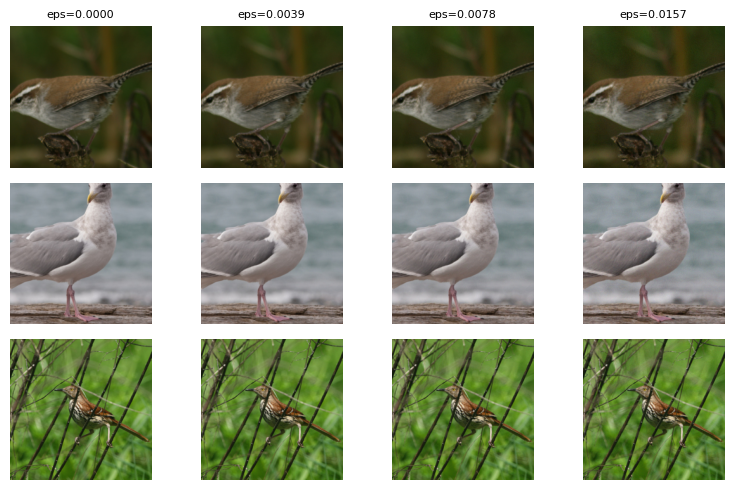

In [55]:
fig, axes = plt.subplots(3, 4, figsize=(8, 5))

for i in range(3):
    for j in range(4):
        img = advs[j][i].detach().cpu().permute(1, 2, 0).numpy()
        axes[i, j].imshow(img)
        axes[i, j].axis("off")
        if i == 0:
            axes[i, j].set_title(f"eps={epsilons[j]:.4f}", fontsize=8)

plt.tight_layout()
plt.show()

## Boundary Attack

Boundary Attack is a powerful decision-based attack for black-box models. It starts from an adversarial point (an image the model already misclassifies) and iteratively moves along the decision boundary to minimize the distance to the original image while staying adversarial. Formula:

$$x_{t+1} = \text{proj} \left( x_t + \eta \cdot \vec{d} \right) \quad \text{s.t.} \quad f(x_{t+1}) \neq f(x)$$

Where $\vec{d}$ is a random step, and the projection ensures the new point stays on the adversarial side of the boundary.

In [56]:
boundary_attack = fb.attacks.BoundaryAttack(
    init_attack=fb.attacks.LinearSearchBlendedUniformNoiseAttack(),
    steps=1000,
    spherical_step=0.01,
    source_step=0.01,
)

A separate evaluation function.

In [58]:
def eval_boundary_attack(model, attack, loader):
    fmodel = make_fmodel(model)
    model.eval()

    clean_correct = 0
    adv_correct = 0
    total = 0

    for x, y in tqdm(loader, leave=False):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        clean_pred = raw_logits(model, x).argmax(1)
        clean_correct += (clean_pred == y).sum().item()

        result = attack(fmodel, x, y, epsilons=None)

        if isinstance(result, tuple):
            adv = result[1] if len(result) >= 2 else result[0]
            if isinstance(adv, tuple):
                adv = adv[0]
        else:
            adv = result

        adv_pred = raw_logits(model, adv).argmax(1)
        adv_correct += (adv_pred == y).sum().item()
        total += y.size(0)

    return clean_correct / total, adv_correct / total

Evaluation.

In [59]:
baseline_clean_boundary, baseline_boundary_acc = eval_boundary_attack(
    baseline, boundary_attack, boundary_loader
)

pd.DataFrame({
    "clean_accuracy": [baseline_clean_boundary],
    "boundary_adv_accuracy": [baseline_boundary_acc],
})

  0%|          | 0/4 [00:00<?, ?it/s]

,clean_accuracy,boundary_adv_accuracy
0,0.75,0.0


Testing for 3 examples.

In [60]:
imgs, labels = next(iter(boundary_loader))
imgs = imgs[:3].to(device)
labels = labels[:3].to(device)

boundary_attack = fb.attacks.BoundaryAttack(
    init_attack=fb.attacks.LinearSearchBlendedUniformNoiseAttack(),
    steps=1000,
)

fmodel = make_fmodel(baseline)
_, advs, _ = boundary_attack(fmodel, imgs, labels, epsilons=None)

Visualisation. Perturbations are visible but do not obscure the image content.

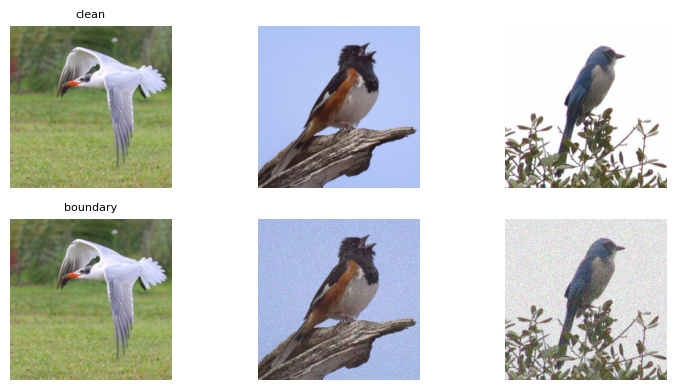

In [62]:
fig, axes = plt.subplots(2, 3, figsize=(8, 4))

for i in range(3):
    clean = imgs[i].detach().cpu().permute(1, 2, 0).numpy()
    adv = advs[i].detach().cpu().permute(1, 2, 0).numpy()

    axes[0, i].imshow(clean)
    axes[0, i].axis("off")
    if i == 0:
        axes[0, i].set_title("clean", fontsize=8)

    axes[1, i].imshow(adv)
    axes[1, i].axis("off")
    if i == 0:
        axes[1, i].set_title("boundary", fontsize=8)

plt.tight_layout()
plt.show()

## Adversarial training

A light PGD-style loop

In [33]:
def pgd_inner(model, x, y, eps=4 / 255, alpha=2 / 255, steps=2):
    x0 = x.detach()
    x_adv = (x0 + torch.empty_like(x0).uniform_(-eps, eps)).clamp(0, 1)

    for _ in range(steps):
        x_adv.requires_grad_(True)
        loss = F.cross_entropy(raw_logits(model, x_adv), y)
        grad = torch.autograd.grad(loss, x_adv)[0]
        x_adv = x_adv.detach() + alpha * grad.sign()
        x_adv = torch.max(torch.min(x_adv, x0 + eps), x0 - eps).clamp(0, 1)

    return x_adv.detach()

def adv_train_epochs(model, train_loader, val_loader, epochs=2, eps=4 / 255, alpha=2 / 255, steps=2, lr=2e-4):
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scaler = torch.cuda.amp.GradScaler(enabled=device.type == "cuda")
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0
        total = 0

        for x, y in tqdm(train_loader, desc=f"adv epoch {epoch}", leave=False):
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            x_adv = pgd_inner(model, x, y, eps=eps, alpha=alpha, steps=steps)
            opt.zero_grad(set_to_none=True)

            with torch.autocast("cuda", enabled=device.type == "cuda"):
                clean_loss = F.cross_entropy(raw_logits(model, x), y)
                adv_loss = F.cross_entropy(raw_logits(model, x_adv), y)
                loss = 0.5 * clean_loss + 0.5 * adv_loss

            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()

            total_loss += loss.item() * y.size(0)
            total += y.size(0)

        val_acc = accuracy_raw(model, val_raw_loader)
        history.append({"epoch": epoch, "loss": total_loss / total, "val_acc": val_acc})
        print(f"adv epoch {epoch}: loss={total_loss / total:.4f}, val_acc={val_acc:.4f}")

    return pd.DataFrame(history)

Baseline model fine-tuning.

In [34]:
adv_model = make_model()
adv_model.load_state_dict(copy.deepcopy(baseline.state_dict()))

<All keys matched successfully>

In [35]:
adv_hist = adv_train_epochs(adv_model, train_raw_loader, val_raw_loader, epochs=2, eps=4 / 255, alpha=2 / 255, steps=2, lr=0.5e-4)

/tmp/ipykernel_2221/1425690472.py:16: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=device.type == "cuda")


adv epoch 1:   0%|          | 0/85 [00:00<?, ?it/s]

adv epoch 1: loss=2.5673, val_acc=0.7033


adv epoch 2:   0%|          | 0/85 [00:00<?, ?it/s]

adv epoch 2: loss=1.7788, val_acc=0.6917


Evaluation. The results are a little worse than those we had for the baseline, but the night is still young.

In [37]:
adv_clean_test = accuracy_raw(adv_model, test_raw_loader)
adv_clean_val = accuracy_raw(adv_model, val_raw_loader)

print(f"adv-trained val accuracy:  {adv_clean_val:.4f}")
print(f"adv-trained test accuracy: {adv_clean_test:.4f}")

adv-trained val accuracy:  0.6917
adv-trained test accuracy: 0.6945


## FGSM

Fast Gradient Sign Method (FGSM) is a simple yet effective one-step attack that creates an adversarial example by shifting the image in the direction of the gradient of the loss function. Formula:

$$x_{adv} = x + \epsilon \cdot \text{sign}(\nabla_{x} L(\theta, x, y))$$

The plus sign indicates an untargeted attack. Unlike PGD, which is iterative, FGSM is computationally inexpensive because it only requires a single backward pass.


In [45]:
fgsm_attack = fb.attacks.FGSM()
fgsm_eps = [
    0.0, 0.25 / 255, 0.5 / 255, 1 / 255, 1.5 / 255,
    2 / 255, 4 / 255, 8 / 255, 8.5 / 255
]

base_clean_curve, base_adv_curve = eval_attack_curve(baseline, fgsm_attack, attack_loader, fgsm_eps)
adv_clean_curve, adv_adv_curve = eval_attack_curve(adv_model, fgsm_attack, attack_loader, fgsm_eps)

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

The adversarially fine-tuned model shows robustness to FGSM with epsilon up to 0.032, while the baseline fails at 0.006.

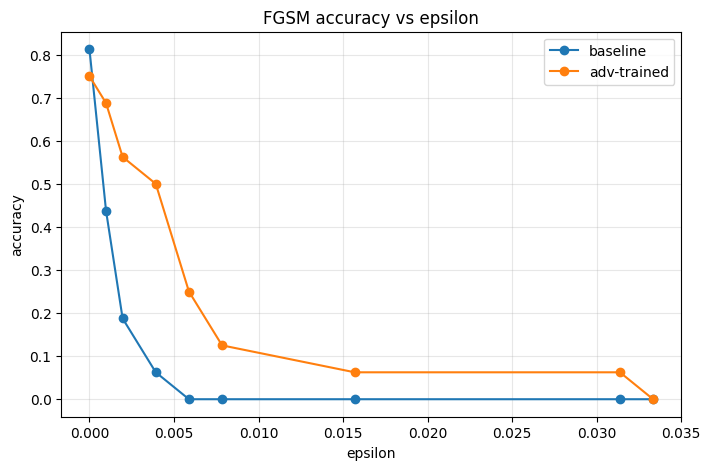

In [46]:
plt.figure(figsize=(8, 5))
plt.plot(fgsm_eps, base_adv_curve, marker="o", label="baseline")
plt.plot(fgsm_eps, adv_adv_curve, marker="o", label="adv-trained")
plt.xlabel("epsilon")
plt.ylabel("accuracy")
plt.title("FGSM accuracy vs epsilon")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Randomized Smoothing. Smoothed Accuracy

Randomized Smoothing is a technique used to build and evaluate models that are robust to small perturbations. Instead of classifying a single image $x$, the model classifies a smoothed version of the input by taking the majority vote over several noisy copies.

The smoothed classifier $g(x)$ is defined as the class most likely to be predicted when the input is corrupted by isotropic Gaussian noise:

$$g(x) = \text{arg max}_{c \in \mathcal{Y}} P(f(x + \varepsilon) = c), \quad \text{where } \varepsilon \sim \mathcal{N}(0, \sigma^2 I)$$

This probability is estimated using Monte Carlo sampling:

$$\hat{g}(x) = \text{arg max}_{c} \sum_{i=1}^{n} \mathbb{I}(f(x + \sigma \cdot \delta_i) = c)$$



In [64]:
def smoothed_accuracy(model, loader, sigma=0.12, samples=16):
    model.eval()
    correct = total = 0
    num_classes = 200

    for x, y in tqdm(loader, leave=False):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        votes = torch.zeros(x.size(0), num_classes, device=device)
        for _ in range(samples):
            noisy = (x + sigma * torch.randn_like(x)).clamp(0, 1)
            pred = raw_logits(model, noisy).argmax(1)
            votes += F.one_hot(pred, num_classes=num_classes).float()

        correct += (votes.argmax(1) == y).sum().item()
        total += y.size(0)

    return correct / total

Run for several sigmas.

In [72]:
smooth_loader = DataLoader(Subset(test_raw_full, smooth_ids.tolist()), batch_size=16, shuffle=False)
smooth_sigmas = [0.0, 0.025, 0.05, 0.10, 0.15, 0.20, 0.25, 0.3]

smooth_rows = []
for sigma in smooth_sigmas:
    smooth_rows.append({
        "sigma": sigma,
        "baseline": smoothed_accuracy(baseline, smooth_loader, sigma=sigma, samples=8),
        "adv_trained": smoothed_accuracy(adv_model, smooth_loader, sigma=sigma, samples=8),
    })

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

...

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

Accuracy for different sigmas. Although we do not train the models on smoothed examples, we observe significantly higher robustness in the adversarially trained model compared to the baseline.

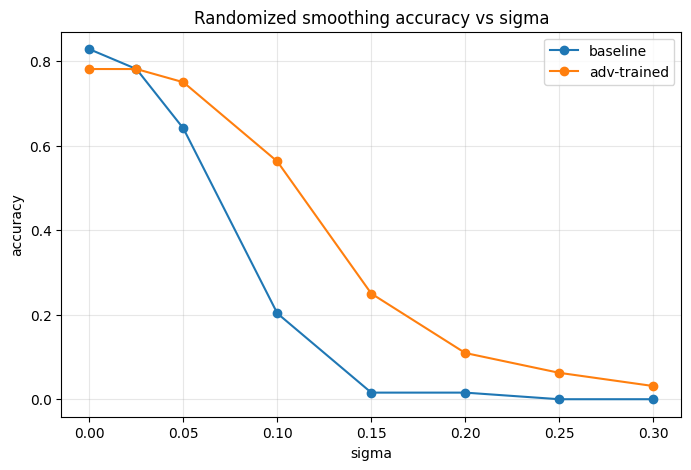

In [73]:
df = pd.DataFrame(smooth_rows)

plt.figure(figsize=(8, 5))
plt.plot(df["sigma"], df["baseline"], marker="o", label="baseline")
plt.plot(df["sigma"], df["adv_trained"], marker="o", label="adv-trained")
plt.xlabel("sigma")
plt.ylabel("accuracy")
plt.title("Randomized smoothing accuracy vs sigma")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()